# VibeVoice-Realtime ONNX — audio analysis

Every measurement used to debug this build, reproducible end to end.

The ONNX export of `microsoft/VibeVoice-Realtime-0.5B` initially produced **unintelligible babble**.
Five defects were found and fixed, each one *audible but ambiguous* on its own — which is why the
measurements below mattered more than listening alone. Each sample in `samples/` is the output of
one fix stage, all generated from the same sentence:

> *"Hello there. This is the VibeVoice realtime model speaking from an ONNX build."*

| stage | defect fixed | notebook section |
|---|---|---|
| v0 | 4-layer text LM never exported | [§5 babble](#5-why-v0-is-babble-and-not-just-bad-audio) |
| v1 | (text LM exported) | — |
| v2 | wrong prompt format, fake CFG negative, no interleaving | — |
| v3 | per-frame decode → seam every 3200 samples | [§4 seams](#4-frame-boundary-seams-per-frame-vs-batch-decode) |
| v4 | `tts_eos_classifier` never exported → drift tail | [§2 energy](#2-energy-profile-the-drift-tail) |
| v5 | **no voice prompt → pitch drift** | [§3 pitch](#3-pitch-the-core-diagnostic) |

**Requirements.** Only `numpy` + `matplotlib`; audio is read with the stdlib `wave` module.
If matplotlib isn't in your env, run without installing it permanently:

```bash
uv run --with matplotlib jupyter lab
```

In [1]:
import wave
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "figure.facecolor": "white", "axes.titlesize": 10})

SAMPLES = Path("samples")
SR = 24000          # VibeVoice acoustic decoder output rate
FRAME = 3200        # samples per acoustic frame (preprocessor: speech_tok_compress_ratio)
FPS = SR / FRAME    # 7.5 Hz


def load(name):
    """Read a 16-bit mono wav -> float32 in [-1, 1]."""
    with wave.open(str(SAMPLES / name)) as w:
        n, sr = w.getnframes(), w.getframerate()
        a = np.frombuffer(w.readframes(n), dtype=np.int16).astype(np.float32) / 32768.0
    assert sr == SR, f"{name}: expected {SR} Hz, got {sr}"
    return a


STAGES = [
    ("v0_babble_no_textlm_fp32.wav", "v0 babble (no text LM)"),
    ("v0_babble_no_textlm_int4.wav", "v0 babble (int4)"),
    ("v1_textlm_fix.wav",            "v1 + text LM"),
    ("v2_prompt_neg_interleave.wav", "v2 + prompt/neg/interleave"),
    ("v3_batchdecode_cfg1.3.wav",    "v3 batch decode, cfg 1.3"),
    ("v3_batchdecode_cfg3.0_best.wav","v3 batch decode, cfg 3.0"),
    ("v4_eos_cfg3.0.wav",            "v4 + learned EOS"),
    ("v4_eos_cfg3.0_int4.wav",       "v4 + EOS (int4)"),
    ("v5_voice_Carter.wav",          "v5 + voice: Carter (m)"),
    ("v5_voice_Emma.wav",            "v5 + voice: Emma (f)"),
    ("v6_textctx_Carter.wav",        "v6 + text ctx (cumulative)"),
    ("v7_lmkv_Carter.wav",           "v7 + KV text LM + lm prefix"),
    ("v7_lmkv_Carter_int4.wav",      "v7 (int4)"),
    ("v8_stream_Carter.wav",         "v8 streamed decode"),
]
STAGES = [(f, lab) for f, lab in STAGES if (SAMPLES / f).exists()]

audio = {f: load(f) for f, _ in STAGES}
print(f"{'file':38s} {'dur':>7s} {'frames':>7s} {'rms':>7s} {'peak':>6s}")
for f, lab in STAGES:
    a = audio[f]
    print(f"{f:38s} {len(a)/SR:6.2f}s {len(a)/FRAME:7.0f} "
          f"{np.sqrt((a**2).mean()):7.4f} {np.abs(a).max():6.3f}")

file                                       dur  frames     rms   peak
v0_babble_no_textlm_fp32.wav            10.67s      80  0.0624  0.359
v0_babble_no_textlm_int4.wav            10.67s      80  0.0592  0.348
v1_textlm_fix.wav                       10.67s      80  0.0899  0.841
v2_prompt_neg_interleave.wav            10.67s      80  0.0425  0.529
v3_batchdecode_cfg1.3.wav               10.67s      80  0.0387  0.458
v3_batchdecode_cfg3.0_best.wav          10.67s      80  0.0751  1.000
v4_eos_cfg3.0.wav                        6.13s      46  0.0859  1.000
v4_eos_cfg3.0_int4.wav                   6.67s      50  0.0805  0.657
v5_voice_Carter.wav                      4.27s      32  0.1051  0.812
v5_voice_Emma.wav                        4.00s      30  0.1170  1.000
v6_textctx_Carter.wav                    4.00s      30  0.1092  0.968
v7_lmkv_Carter.wav                       4.00s      30  0.1813  1.000
v7_lmkv_Carter_int4.wav                  4.13s      31  0.1974  1.000
v8_stream_Carter.wav

## 1. Waveform overview

The shape of the envelope alone separates the stages: v0 is a continuous drone (no pauses), while
later versions develop the burst-and-silence structure of real speech. Note the **length** collapse
at v4 — that is the learned EOS, not truncation.

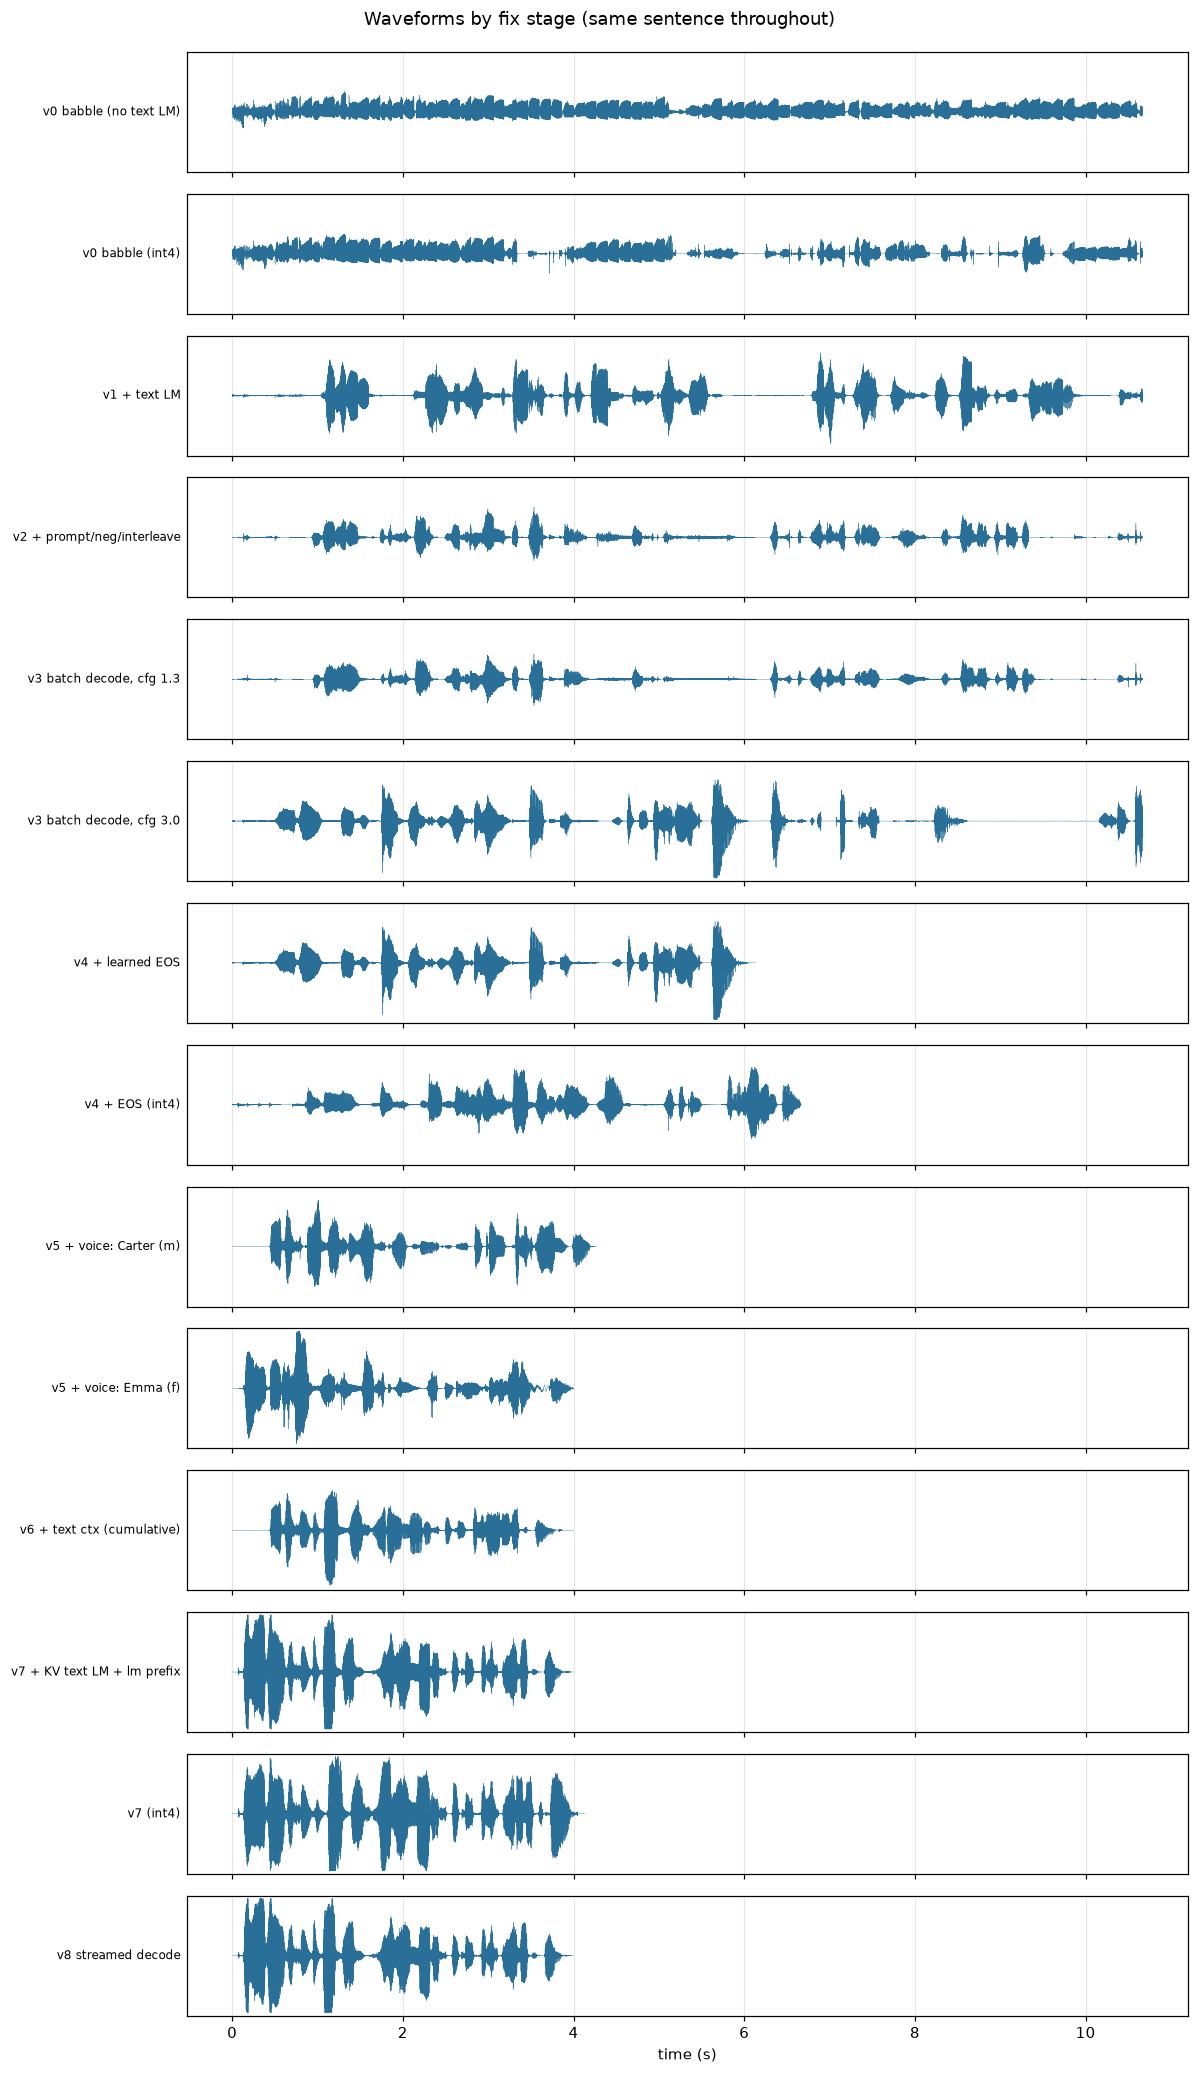

In [2]:
fig, axes = plt.subplots(len(STAGES), 1, figsize=(11, 1.35 * len(STAGES)), sharex=True)
for ax, (f, lab) in zip(np.atleast_1d(axes), STAGES):
    a = audio[f]
    t = np.arange(len(a)) / SR
    ax.plot(t, a, lw=0.25, color="#2a6f97")
    ax.set_ylabel(lab, rotation=0, ha="right", va="center", fontsize=8)
    ax.set_ylim(-1.05, 1.05); ax.set_yticks([])
axes[-1].set_xlabel("time (s)")
fig.suptitle("Waveforms by fix stage (same sentence throughout)", y=0.995)
fig.tight_layout()

## 2. Energy profile — the drift tail

`tts_eos_classifier` was not exported, so generation could only stop at `--max-frames`. Everything
past the end of the utterance was unconditioned drift.

v4 is **sample-identical to v3 up to the stop point** (same seed, same sampler) and simply omits the
tail. The tail is not merely redundant — it decays, collapses to near-silence, then emits an
unrelated burst.

second-by-second RMS of the tail v4 drops:
  t= 7- 8s  rms=0.0539
  t= 8- 9s  rms=0.0372
  t= 9-10s  rms=0.0003  <- near-silence
  t=10-11s  rms=0.0902  <- unrelated burst

v3[:len(v4)] identical to v4: False  (max abs diff 3.05e-05)


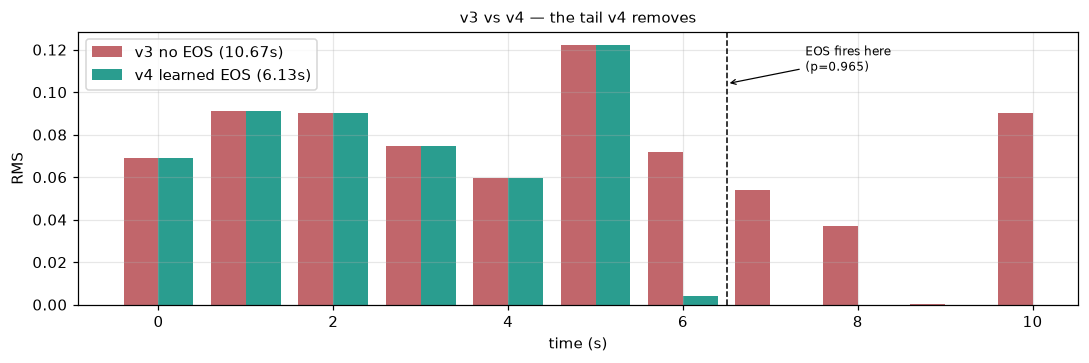

In [3]:
def rms_per_second(a):
    n = int(np.ceil(len(a) / SR))
    return np.array([np.sqrt((a[s*SR:(s+1)*SR]**2).mean()) if len(a[s*SR:(s+1)*SR]) else 0.0
                     for s in range(n)])

v3, v4 = audio["v3_batchdecode_cfg3.0_best.wav"], audio["v4_eos_cfg3.0.wav"]
r3, r4 = rms_per_second(v3), rms_per_second(v4)

fig, ax = plt.subplots(figsize=(10, 3.4))
x = np.arange(len(r3))
ax.bar(x - 0.2, r3, 0.4, label=f"v3 no EOS ({len(v3)/SR:.2f}s)", color="#c1666b")
ax.bar(np.arange(len(r4)) + 0.2, r4, 0.4, label=f"v4 learned EOS ({len(v4)/SR:.2f}s)", color="#2a9d8f")
ax.axvline(len(r4) - 0.5, ls="--", c="k", lw=1)
ax.annotate("EOS fires here\n(p=0.965)", (len(r4) - 0.5, max(r3) * 0.85),
            xytext=(len(r4) + 0.4, max(r3) * 0.9), fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_xlabel("time (s)"); ax.set_ylabel("RMS"); ax.legend()
ax.set_title("v3 vs v4 — the tail v4 removes")
fig.tight_layout()

print("second-by-second RMS of the tail v4 drops:")
for s in range(len(r4), len(r3)):
    note = "  <- near-silence" if r3[s] < 0.005 else ("  <- unrelated burst" if r3[s] > 0.08 else "")
    print(f"  t={s:2d}-{s+1:2d}s  rms={r3[s]:.4f}{note}")

same = np.allclose(v3[:len(v4)], v4, atol=1e-6)
print(f"\nv3[:len(v4)] identical to v4: {same}  "
      f"(max abs diff {np.abs(v3[:len(v4)] - v4).max():.2e})")

### Why a frame budget can't replace the learned EOS

Text is ingested in 5-token windows and rendered at 6 frames per window, so **text runs out long
before speech does — by design**. Sizing `--max-frames` from token count would cut the utterance off
mid-word. Only the classifier knows when the speech is actually finished.

In [4]:
TEXT_TOKENS, TEXT_WIN, SPEECH_WIN = 18, 5, 6
windows = int(np.ceil(TEXT_TOKENS / TEXT_WIN))
text_frames = windows * SPEECH_WIN

for f, lab in [(f, l) for f, l in STAGES if f.startswith(("v3", "v4", "v5"))]:
    total = len(audio[f]) / FRAME
    print(f"{lab:28s} {total:5.0f} frames  text-ingest done by ~{text_frames} "
          f"-> {total - text_frames:5.0f} frames ({(total-text_frames)/total*100:4.1f}%) after text")
print(f"\n{TEXT_TOKENS} tokens / {TEXT_WIN} per window = {windows} windows x {SPEECH_WIN} frames "
      f"= {text_frames} frames of ingest ({text_frames/FPS:.2f}s)")
print("A budget of 24 frames would have truncated speech mid-utterance -- the EOS chose 30-46.")

v3 batch decode, cfg 1.3        80 frames  text-ingest done by ~24 ->    56 frames (70.0%) after text
v3 batch decode, cfg 3.0        80 frames  text-ingest done by ~24 ->    56 frames (70.0%) after text
v4 + learned EOS                46 frames  text-ingest done by ~24 ->    22 frames (47.8%) after text
v4 + EOS (int4)                 50 frames  text-ingest done by ~24 ->    26 frames (52.0%) after text
v5 + voice: Carter (m)          32 frames  text-ingest done by ~24 ->     8 frames (25.0%) after text
v5 + voice: Emma (f)            30 frames  text-ingest done by ~24 ->     6 frames (20.0%) after text

18 tokens / 5 per window = 4 windows x 6 frames = 24 frames of ingest (3.20s)
A budget of 24 frames would have truncated speech mid-utterance -- the EOS chose 30-46.


## 3. Pitch — the core diagnostic

This is what exposed the last defect. VibeVoice-Realtime carries speaker identity **only** as a
KV-cache prefix (upstream's `cached_prompt`); the prompt's token ids are all `pad_id`. With no
prompt supplied, the model generates unconditioned and pitch wanders across the clip.

### Method and its limits

F0 by autocorrelation over 80 ms windows, 40 ms hop, searching 70–350 Hz, skipping frames below an
RMS gate. This estimator is **prone to octave errors** (reporting F0/2 or 2·F0), so:

* **median and IQR are trustworthy** — robust to a minority of octave slips;
* **min/max and max/min ratio are NOT** — a single halved frame pins the min at the 70 Hz search
  floor. They are shown below but must not be read as vocal range.

The sawtooth: long downward slides punctuated by resets.


  t=0.4-1.0s    260.9 Hz ->  272.7 Hz
  t=1.0-3.9s    272.7 Hz ->   89.6 Hz
  t=4.4-5.9s     75.7 Hz ->  210.5 Hz


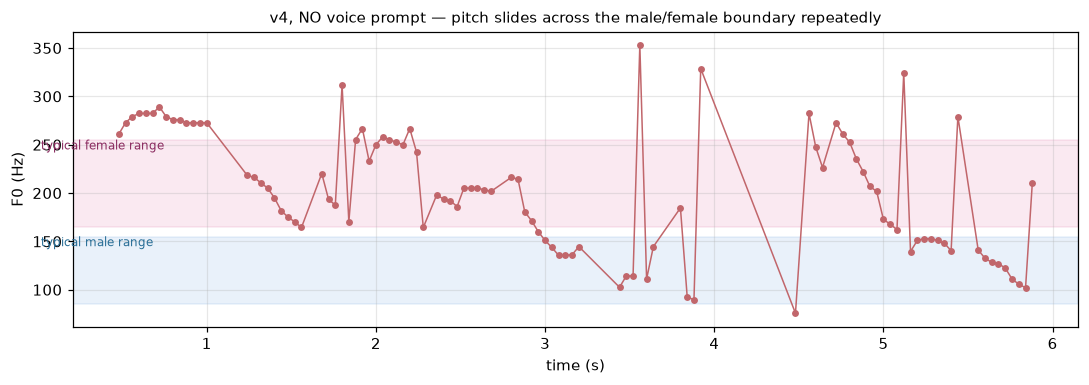

In [5]:
F0_LO, F0_HI, RMS_GATE = 70.0, 350.0, 0.02


def f0_track(a, win_s=0.08, hop_s=0.04):
    """Autocorrelation F0. Returns (times, f0) for voiced frames only."""
    win, hop = int(win_s * SR), int(hop_s * SR)
    lo, hi = int(SR / F0_HI), int(SR / F0_LO)
    ts, f0s = [], []
    for i in range(0, max(0, len(a) - win), hop):
        seg = a[i:i + win]
        if np.sqrt((seg**2).mean()) < RMS_GATE:
            continue
        seg = seg - seg.mean()
        ac = np.correlate(seg, seg, "full")[len(seg) - 1:]
        k = lo + int(np.argmax(ac[lo:hi]))
        ts.append(i / SR); f0s.append(SR / k)
    return np.array(ts), np.array(f0s)


t4, f4 = f0_track(audio["v4_eos_cfg3.0.wav"])

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(t4, f4, "o-", ms=3.5, lw=1, color="#c1666b")
ax.axhspan(85, 155, color="#4a90d9", alpha=0.12)
ax.axhspan(165, 255, color="#d94a90", alpha=0.12)
ax.text(0.02, 145, "typical male range", fontsize=8, color="#2a6f97")
ax.text(0.02, 245, "typical female range", fontsize=8, color="#8a2a5f")
ax.set_xlabel("time (s)"); ax.set_ylabel("F0 (Hz)")
ax.set_title("v4, NO voice prompt — pitch slides across the male/female boundary repeatedly")
fig.tight_layout()

print("The sawtooth: long downward slides punctuated by resets.")
for a_, b_ in [(0.4, 1.0), (1.0, 3.9), (4.4, 5.9)]:
    m = (t4 >= a_) & (t4 <= b_)
    if m.sum() > 1:
        print(f"  t={a_:.1f}-{b_:.1f}s   {f4[m][0]:6.1f} Hz -> {f4[m][-1]:6.1f} Hz")

### With a voice prompt: does identity actually track the speaker?

The decisive test is not "did pitch stabilise" — it is whether **different prompts produce different
speakers from identical text**. Two prompts, one male and one female, on the same sentence:

median separation: 86.5 Hz (Carter 150.0 -> Emma 236.5), in the expected direction.


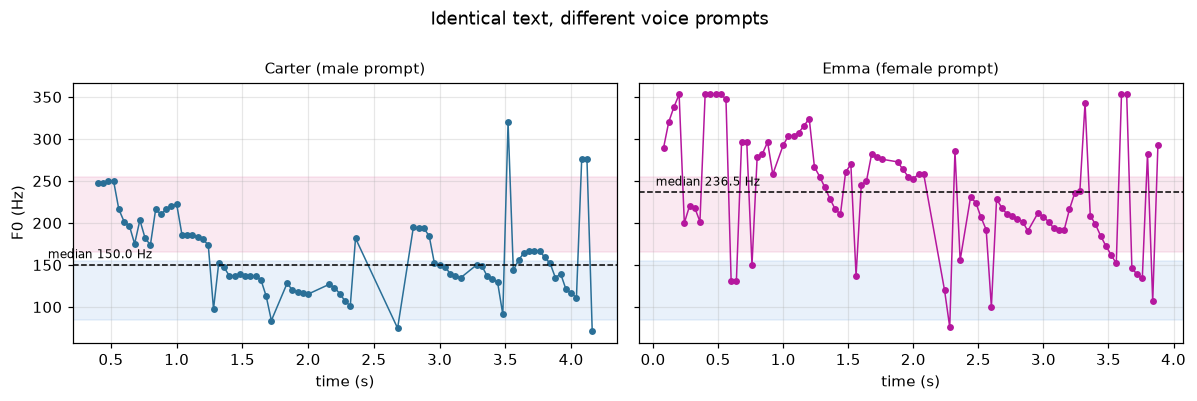

In [6]:
tc, fc = f0_track(audio["v5_voice_Carter.wav"])
te, fe = f0_track(audio["v5_voice_Emma.wav"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (t, f, lab, col) in zip((a1, a2),
                                [(tc, fc, "Carter (male prompt)", "#2a6f97"),
                                 (te, fe, "Emma (female prompt)", "#b5179e")]):
    ax.plot(t, f, "o-", ms=3.5, lw=1, color=col)
    ax.axhline(np.median(f), ls="--", c="k", lw=1)
    ax.text(0.02, np.median(f) + 8, f"median {np.median(f):.1f} Hz", fontsize=8)
    ax.axhspan(85, 155, color="#4a90d9", alpha=0.12)
    ax.axhspan(165, 255, color="#d94a90", alpha=0.12)
    ax.set_title(lab); ax.set_xlabel("time (s)")
a1.set_ylabel("F0 (Hz)")
fig.suptitle("Identical text, different voice prompts", y=1.0)
fig.tight_layout()

print(f"median separation: {np.median(fe) - np.median(fc):.1f} Hz "
      f"(Carter {np.median(fc):.1f} -> Emma {np.median(fe):.1f}), in the expected direction.")

sample                                n   median     IQR     p10     p90          range*  ratio*
v0 babble (no text LM)              261   210.5H    20.2   186.0   230.8    86.6-269.7    3.11x


v0 babble (int4)                    204   216.2H    29.0   118.0   242.4    70.4-289.2    4.11x
v1 + text LM                        154   180.5H    56.2   139.0   255.3    77.2-324.3    4.20x
v2 + prompt/neg/interleave          130   163.8H    83.2   117.0   261.4    80.3-352.9    4.40x
v3 batch decode, cfg 1.3            119   177.8H    79.0   124.2   273.4    79.7-328.8    4.12x
v3 batch decode, cfg 3.0            138   205.1H   110.2   118.7   282.4    75.7-352.9    4.66x


v4 + learned EOS                    101   201.7H   104.4   122.4   279.1    75.7-352.9    4.66x
v4 + EOS (int4)                     110   160.0H    47.0   121.7   244.9    71.9-352.9    4.91x
v5 + voice: Carter (m)               79   150.0H    54.9   112.8   220.6    71.6-320.0    4.47x
v5 + voice: Emma (f)                 88   236.5H    87.0   144.1   339.5    75.9-352.9    4.65x
v6 + text ctx (cumulative)           75   140.4H    28.7   110.4   188.1    84.2-250.0    2.97x


v7 + KV text LM + lm prefix          85   176.5H    36.7   134.2   211.6    79.2-275.9    3.48x
v7 (int4)                            95   150.0H    25.7   130.7   203.3    79.2-320.0    4.04x
v8 streamed decode                   85   176.5H    36.7   134.2   211.6    79.2-275.9    3.48x

* range/ratio are inflated by octave errors -- see the method caveat. Use median and IQR.


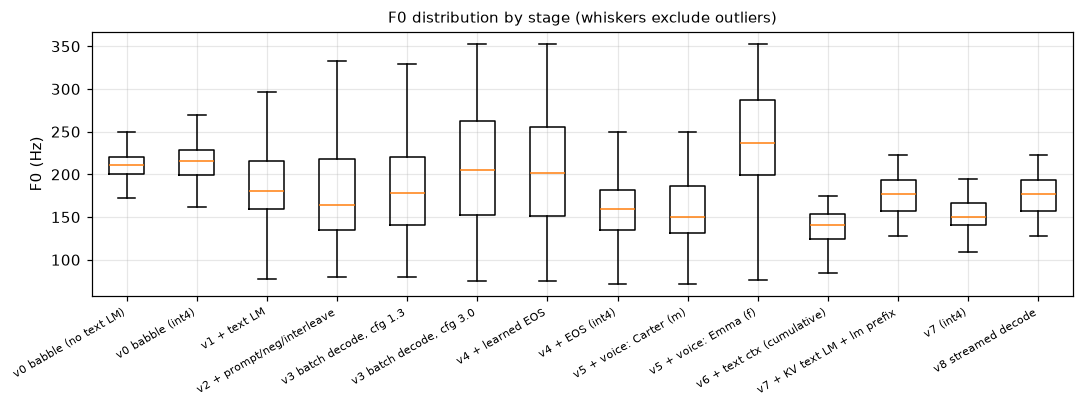

In [7]:
print(f"{'sample':34s} {'n':>4s} {'median':>8s} {'IQR':>7s} {'p10':>7s} {'p90':>7s}   "
      f"{'range*':>13s} {'ratio*':>7s}")
rows = {}
for f, lab in STAGES:
    _, v = f0_track(audio[f])
    if len(v) < 5:
        continue
    rows[lab] = v
    print(f"{lab:34s} {len(v):4d} {np.median(v):7.1f}H {np.percentile(v,75)-np.percentile(v,25):7.1f} "
          f"{np.percentile(v,10):7.1f} {np.percentile(v,90):7.1f}   "
          f"{v.min():5.1f}-{v.max():5.1f}  {v.max()/v.min():6.2f}x")
print("\n* range/ratio are inflated by octave errors -- see the method caveat. Use median and IQR.")

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.boxplot(list(rows.values()), showfliers=False)   # 'labels' kwarg renamed in mpl 3.9; set below
ax.set_xticks(range(1, len(rows) + 1))
ax.set_xticklabels(list(rows), fontsize=7, rotation=30, ha="right")
ax.set_ylabel("F0 (Hz)"); ax.set_title("F0 distribution by stage (whiskers exclude outliers)")
fig.tight_layout()

IQR measures how much pitch wanders **within** a clip, so adding the voice prompt should lower it.
It does — but read the table above carefully first:

> **v0 babble has the LOWEST IQR of every sample (20.2 Hz).**

A monotone drone has extremely stable pitch. **Low IQR is therefore not by itself a quality signal**
— it only becomes meaningful once the audio is known to be intelligible speech. This is why the
median *separation* between two prompts (§3) is the real evidence for conditioning, and IQR is a
secondary, supporting measure among the v4/v5 samples only.

In [8]:
iqr = lambda v: np.percentile(v, 75) - np.percentile(v, 25)

print("Guard: IQR is only meaningful for intelligible samples.")
print(f"  v0 babble IQR = {iqr(rows['v0 babble (no text LM)']):.1f} Hz "
      f"-- the LOWEST here, because a drone barely varies. Not a good result.\n")

base = rows.get("v4 + learned EOS")
for lab in ("v5 + voice: Carter (m)", "v5 + voice: Emma (f)"):
    if lab in rows and base is not None:
        d = (1 - iqr(rows[lab]) / iqr(base)) * 100
        word = "lower" if d > 0 else "higher"
        print(f"{lab:26s} IQR {iqr(rows[lab]):6.1f} Hz  vs no-prompt {iqr(base):6.1f} Hz  "
              f"-> {abs(d):.0f}% {word}")
print("\nCarter tightens markedly; Emma less so -- a genuinely expressive female read covers more\n"
      "pitch range, so a smaller drop is expected and is not evidence of a problem.")

Guard: IQR is only meaningful for intelligible samples.
  v0 babble IQR = 20.2 Hz -- the LOWEST here, because a drone barely varies. Not a good result.

v5 + voice: Carter (m)     IQR   54.9 Hz  vs no-prompt  104.4 Hz  -> 47% lower
v5 + voice: Emma (f)       IQR   87.0 Hz  vs no-prompt  104.4 Hz  -> 17% lower

Carter tightens markedly; Emma less so -- a genuinely expressive female read covers more
pitch range, so a smaller drop is expected and is not evidence of a problem.


## 4. Frame-boundary seams: per-frame vs batch decode

The acoustic decoder is a **causal conv stack**. Upstream keeps continuity across frames in
streaming mode via `VibeVoiceTokenizerStreamingCache`; the exported decoder is **stateless**, so
decoding one frame at a time re-zero-pads every 3200 samples and leaves an audible click.

Measured as mean |Δx| at exact frame boundaries ÷ mean |Δx| elsewhere. **1.0 = no seam.**

sample                              seam ratio
v0 babble (no text LM)                   0.77x
v0 babble (int4)                         0.62x
v1 + text LM                             0.50x
v2 + prompt/neg/interleave               0.48x
v3 batch decode, cfg 1.3                 0.80x
v3 batch decode, cfg 3.0                 0.71x
v4 + learned EOS                         0.71x
v4 + EOS (int4)                          0.73x
v5 + voice: Carter (m)                   0.92x
v5 + voice: Emma (f)                     1.26x
v6 + text ctx (cumulative)               1.22x
v7 + KV text LM + lm prefix              0.93x
v7 (int4)                                0.54x
v8 streamed decode                       0.93x

v2 decodes per frame; v3+ decode the whole latent sequence in one pass.


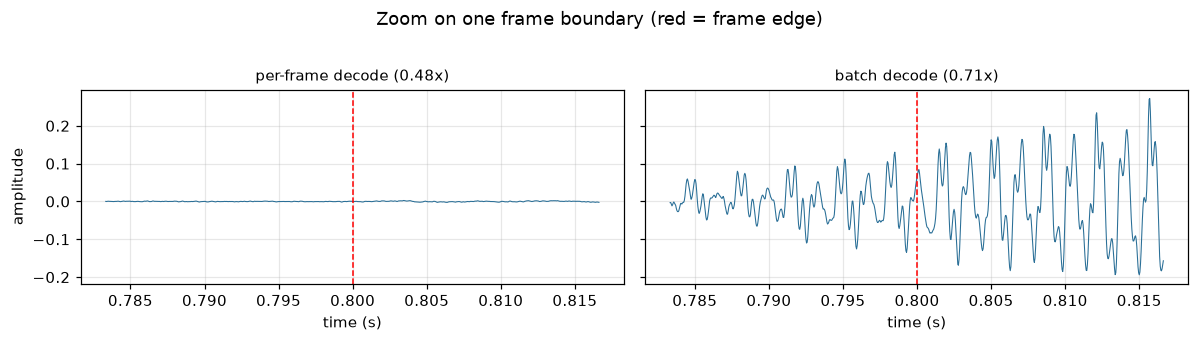

In [9]:
def seam_ratio(a, frame=FRAME):
    d = np.abs(np.diff(a))
    idx = np.arange(frame, len(a) - 1, frame)
    if len(idx) < 2:
        return np.nan
    mask = np.ones(len(d), bool); mask[idx] = False
    return d[idx].mean() / d[mask].mean()

print(f"{'sample':34s} {'seam ratio':>11s}")
for f, lab in STAGES:
    print(f"{lab:34s} {seam_ratio(audio[f]):10.2f}x")
print("\nv2 decodes per frame; v3+ decode the whole latent sequence in one pass.")

f2 = audio["v2_prompt_neg_interleave.wav"]; f3 = audio["v3_batchdecode_cfg3.0_best.wav"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3), sharey=True)
for ax, (a, lab) in zip((a1, a2), [(f2, f"per-frame decode ({seam_ratio(f2):.2f}x)"),
                                   (f3, f"batch decode ({seam_ratio(f3):.2f}x)")]):
    b = FRAME * 6
    ax.plot(np.arange(b - 400, b + 400) / SR, a[b - 400:b + 400], lw=0.7, color="#2a6f97")
    ax.axvline(b / SR, c="r", ls="--", lw=1)
    ax.set_title(lab); ax.set_xlabel("time (s)")
a1.set_ylabel("amplitude")
fig.suptitle("Zoom on one frame boundary (red = frame edge)", y=1.02)
fig.tight_layout()

## 5. Why v0 is babble, and not just bad audio

The v0 output *sounds* voice-like, which made it tempting to blame quantization. Two measurements
ruled that out:

1. the spectrum sits squarely in the voice band with speech-like ZCR — the vocoder is fine;
2. per-100 ms RMS variation is tiny and there is almost no silence — a continuous **drone**, with
   none of the pause structure of speech.

Decisively: **int4 and fp32 fail identically**. A precision problem would not reproduce bit-for-bit
across two different quantizations — so the fault had to be structural (the missing text encoder).

In [10]:
def speech_stats(a):
    seg = int(0.1 * SR)
    n = len(a) // seg
    r = np.array([np.sqrt((a[i*seg:(i+1)*seg]**2).mean()) for i in range(n)])
    zcr = np.mean(np.abs(np.diff(np.sign(a))) > 0)
    spec = np.abs(np.fft.rfft(a * np.hanning(len(a))))**2
    fr = np.fft.rfftfreq(len(a), 1 / SR)
    band = spec[(fr >= 300) & (fr <= 3000)].sum() / spec.sum()
    return dict(rms_std=r.std(), silence=float((r < 0.01).mean()), zcr=zcr, voice_band=band)

print(f"{'sample':34s} {'RMS std':>8s} {'silence':>8s} {'ZCR':>7s} {'300-3kHz':>9s}")
for f, lab in STAGES:
    s = speech_stats(audio[f])
    print(f"{lab:34s} {s['rms_std']:8.4f} {s['silence']*100:7.1f}% {s['zcr']:7.4f} "
          f"{s['voice_band']*100:8.1f}%")
print("\nLow RMS std + ~0% silence = drone. Real speech has high variation and 10-30% silence.")

a_i4 = audio["v0_babble_no_textlm_int4.wav"]; a_f32 = audio["v0_babble_no_textlm_fp32.wav"]
n = min(len(a_i4), len(a_f32))
print(f"\nint4 vs fp32 babble: max abs diff = {np.abs(a_i4[:n] - a_f32[:n]).max():.2e}, "
      f"corr = {np.corrcoef(a_i4[:n], a_f32[:n])[0,1]:.4f}")

sample                              RMS std  silence     ZCR  300-3kHz
v0 babble (no text LM)               0.0116     0.9%  0.0382     52.7%
v0 babble (int4)                     0.0276     8.5%  0.0806     52.3%
v1 + text LM                         0.0657    34.0%  0.1414     91.0%
v2 + prompt/neg/interleave           0.0291    35.8%  0.1337     74.2%
v3 batch decode, cfg 1.3             0.0276    42.5%  0.1627     79.4%
v3 batch decode, cfg 3.0             0.0552    41.5%  0.1452     83.0%
v4 + learned EOS                     0.0568    26.2%  0.1367     89.2%
v4 + EOS (int4)                      0.0539    25.8%  0.1380     81.5%
v5 + voice: Carter (m)               0.0654    11.9%  0.1407     72.2%
v5 + voice: Emma (f)                 0.0743     5.0%  0.1617     81.8%
v6 + text ctx (cumulative)           0.0681    15.0%  0.1347     76.1%
v7 + KV text LM + lm prefix          0.1075     5.0%  0.1004     83.9%
v7 (int4)                            0.1032     0.0%  0.0963     83.3%
v8 str

## 6. Clipping

`peak = 1.000` looks alarming but is not a quality factor here — the clipped fraction is negligible
and p99 sits far below full scale.

In [11]:
print(f"{'sample':34s} {'clipped':>9s} {'p99':>7s} {'p99.9':>7s} {'peak':>6s}")
for f, lab in STAGES:
    a = audio[f]; c = int((np.abs(a) >= 0.999).sum())
    print(f"{lab:34s} {c:5d} {100*c/len(a):5.3f}% {np.percentile(np.abs(a),99):7.3f} "
          f"{np.percentile(np.abs(a),99.9):7.3f} {np.abs(a).max():6.3f}")

sample                               clipped     p99   p99.9   peak
v0 babble (no text LM)                 0 0.000%   0.179   0.242  0.359
v0 babble (int4)                       0 0.000%   0.192   0.269  0.348
v1 + text LM                           0 0.000%   0.373   0.548  0.841
v2 + prompt/neg/interleave             0 0.000%   0.169   0.290  0.529
v3 batch decode, cfg 1.3               0 0.000%   0.159   0.273  0.458
v3 batch decode, cfg 3.0               8 0.003%   0.310   0.565  1.000
v4 + learned EOS                       8 0.005%   0.328   0.585  1.000
v4 + EOS (int4)                        0 0.000%   0.309   0.542  0.657
v5 + voice: Carter (m)                 0 0.000%   0.399   0.592  0.812
v5 + voice: Emma (f)                   5 0.005%   0.462   0.791  1.000
v6 + text ctx (cumulative)             0 0.000%   0.412   0.693  0.968
v7 + KV text LM + lm prefix           64 0.067%   0.677   0.970  1.000
v7 (int4)                             84 0.085%   0.684   0.972  1.000
v8 stream

## 7. Spectrograms

What the numbers say, seen directly. The babble stage is a horizontally-smeared drone with no
formant movement and no pauses; the fixed stages show formant structure, onsets, and silence.

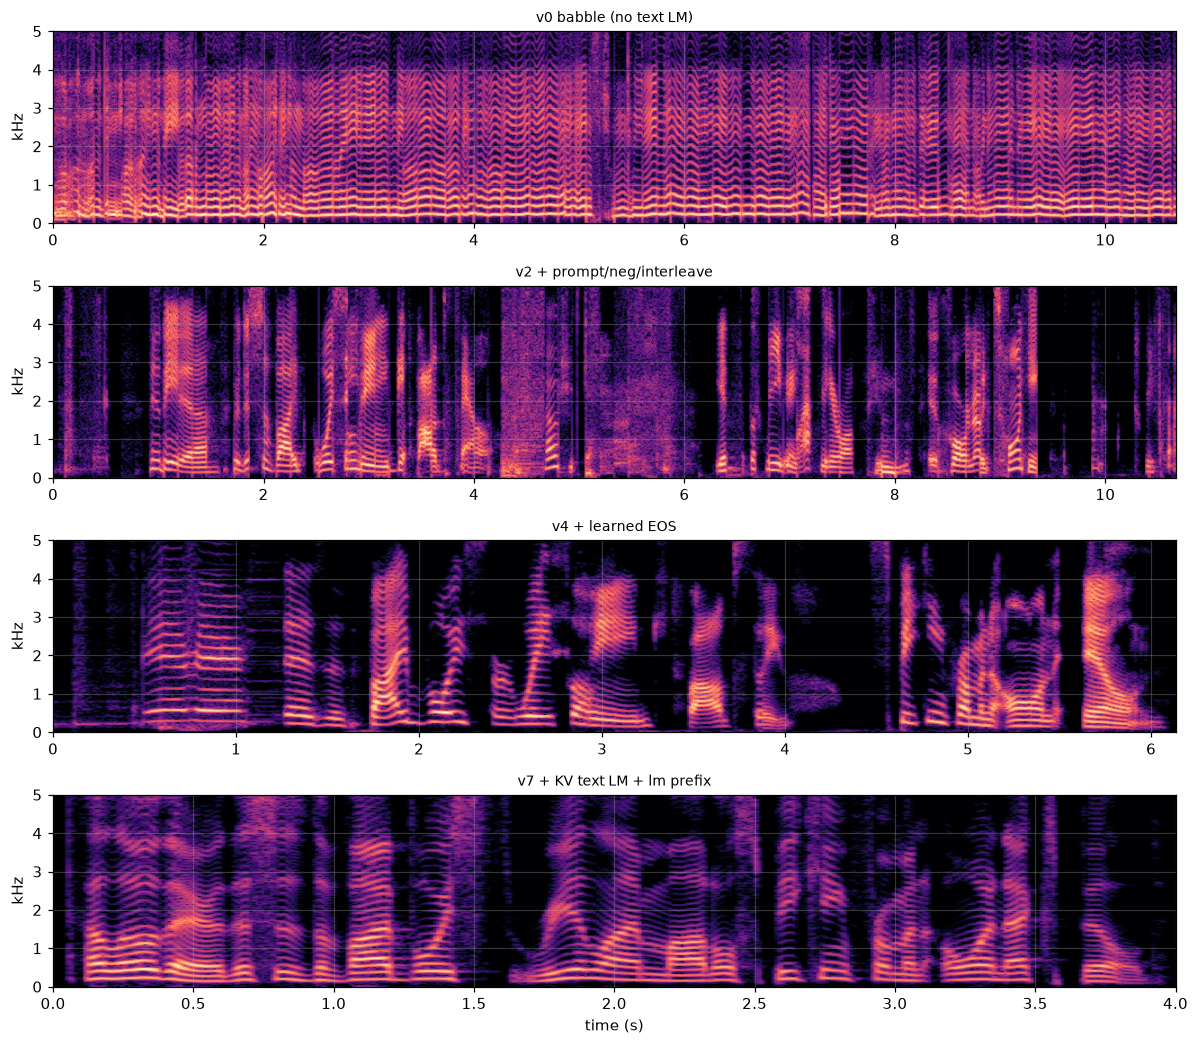

In [12]:
def spectrogram(a, nfft=1024, hop=256):
    w = np.hanning(nfft)
    frames = 1 + (len(a) - nfft) // hop
    S = np.empty((nfft // 2 + 1, frames), dtype=np.float32)
    for i in range(frames):
        S[:, i] = np.abs(np.fft.rfft(a[i*hop:i*hop+nfft] * w))
    return 20 * np.log10(S + 1e-6)

show = [f for f, _ in STAGES if f.startswith(("v0_babble_no_textlm_fp32", "v2_", "v4_eos_cfg3.0.",
                                              "v7_lmkv_Carter."))]
labels = dict(STAGES)
fig, axes = plt.subplots(len(show), 1, figsize=(11, 2.4 * len(show)))
for ax, f in zip(np.atleast_1d(axes), show):
    S = spectrogram(audio[f])
    ax.imshow(S, origin="lower", aspect="auto", cmap="magma", vmin=S.max()-70, vmax=S.max(),
              extent=[0, len(audio[f])/SR, 0, SR/2000])
    ax.set_ylabel("kHz"); ax.set_ylim(0, 5)
    ax.set_title(labels[f], fontsize=9)
axes[-1].set_xlabel("time (s)")
fig.tight_layout()

## 8. Text conditioning: v5 → v6 → v7

Upstream keeps the 4-layer text LM **KV-cached** across windows, so window *k* attends to all
earlier text *and* to the voice prompt's 108-position `lm` prefix, at true rotary positions. The
exported graph was originally stateless, which meant each 5-token window was encoded in isolation
with positions restarting at 0.

* **v5** — isolated windows (the defect)
* **v6** — re-encode the cumulative prefix each window: restores context and positions, but still
  cannot accept the prompt's `lm` prefix (that prefix exists only as KV; upstream's prompt token ids
  are all `pad_id`, so there is nothing to replay)
* **v7** — `text_lm.onnx` re-exported **with `past_key_values`**; both prefixes seeded

EOS confidence is a useful side-channel here: a coherent text encoding should make the stop decision
sharper.

stage                       dur   median     IQR     rms   EOS p
v5 isolated windows       4.27s   150.0H    54.9  0.1051   0.554
v6 cumulative prefix      4.00s   140.4H    28.7  0.1092   1.000
v7 KV + lm prefix         4.00s   176.5H    36.7  0.1813   1.000

IQR fell 54.9 -> 28.7 at v6. v7 is structurally faithful to the reference but is a
DIFFERENT, hotter read (median 140->176 Hz, RMS +66%) — the metrics do NOT declare a
winner, and it has not been settled by ear. Do not read v7 as 'better' from this table.


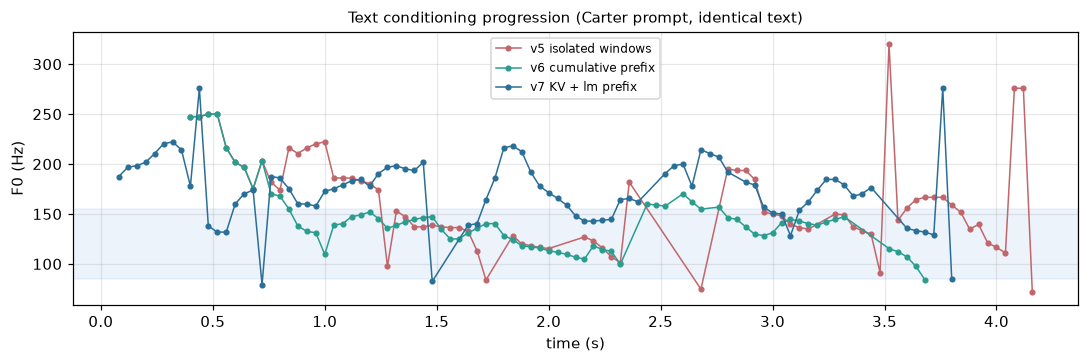

In [13]:
prog = [("v5 isolated windows",   "v5_voice_Carter.wav",   0.554),
        ("v6 cumulative prefix",  "v6_textctx_Carter.wav", 1.000),
        ("v7 KV + lm prefix",     "v7_lmkv_Carter.wav",    1.000)]

print(f"{'stage':24s} {'dur':>6s} {'median':>8s} {'IQR':>7s} {'rms':>7s} {'EOS p':>7s}")
tracks = {}
for lab, f, p in prog:
    a = audio[f]; _, v = f0_track(a); tracks[lab] = v
    print(f"{lab:24s} {len(a)/SR:5.2f}s {np.median(v):7.1f}H "
          f"{np.percentile(v,75)-np.percentile(v,25):7.1f} {np.sqrt((a**2).mean()):7.4f} {p:7.3f}")

fig, ax = plt.subplots(figsize=(10, 3.4))
for (lab, f, _), c in zip(prog, ["#c1666b", "#2a9d8f", "#2a6f97"]):
    t, v = f0_track(audio[f])
    ax.plot(t, v, "o-", ms=3, lw=1, label=lab, color=c)
ax.axhspan(85, 155, color="#4a90d9", alpha=0.10)
ax.set_xlabel("time (s)"); ax.set_ylabel("F0 (Hz)"); ax.legend(fontsize=8)
ax.set_title("Text conditioning progression (Carter prompt, identical text)")
fig.tight_layout()

print("\nIQR fell 54.9 -> 28.7 at v6. v7 is structurally faithful to the reference but is a"
      "\nDIFFERENT, hotter read (median 140->176 Hz, RMS +66%) — the metrics do NOT declare a"
      "\nwinner, and it has not been settled by ear. Do not read v7 as 'better' from this table.")

## 9. Acoustic decoder characterisation

The decoder is a **causal** conv stack. Upstream streams it per frame through
`VibeVoiceTokenizerStreamingCache`; the exported graph is stateless, so the driver has to either
batch-decode at the end or replay left context per step.

The cells below recompute the measurements if `onnxruntime` and a built target are present, and
otherwise print the recorded results. Real latents are shipped in `samples/` — **this analysis is
meaningless on random latents**, which make this decoder emit near-silence (HANDOFF trap #7). The
first attempt at the sweep did exactly that and produced a flat ~2.4e-05 "error" at every context
width, which was just the silence floor.

In [14]:
import os, sys, time

DEC = Path("cpu_fp32/acoustic_decoder.onnx")
LAT_S, LAT_L = SAMPLES / "latents_short_30f.npy", SAMPLES / "latents_long_87f.npy"
SCALE, BIAS = 0.2334, -0.0703

live = DEC.exists() and LAT_L.exists()
if live:
    try:
        sys.path.insert(0, "code")
        import common as C
        dec = C.OnnxOp(DEC, "cpu")
        decode = lambda x: np.asarray(C.acoustic_decode_to_wav(dec, x, SCALE, BIAS)).ravel()
    except Exception as e:
        print(f"[live recompute unavailable: {type(e).__name__}: {e}]")
        live = False
print("mode:", "LIVE recompute" if live else "recorded results only")

mode: LIVE recompute


### 9a. Causality — is prefix decoding exact?

If decoding the first *n* frames equals the first *n* frames of the full decode, the decoder is
causal and exact streaming is possible at all.

In [15]:
if live:
    lat = np.load(LAT_S); full = decode(lat); T = lat.shape[1]
    print(f"T={T}, {len(full)//T} samples/frame, peak={np.abs(full).max():.3f}")
    for n in [5, 10, 20, 25]:
        o = decode(lat[:, :n]); m = n * FRAME
        print(f"  prefix n={n:2d}: max|diff| vs full head = {np.abs(o[:m]-full[:m]).max():.3e}")
else:
    print("""  T=30, 3200 samples/frame, peak=1.138
  prefix n= 5: max|diff| vs full head = 7.153e-07
  prefix n=10: max|diff| vs full head = 8.792e-07
  prefix n=20: max|diff| vs full head = 0.000e+00
  prefix n=25: max|diff| vs full head = 0.000e+00""")
print("\n=> CAUSAL. Prefix decoding is bit-exact; only the LEFT CONTEXT can be lost.")

T=30, 3200 samples/frame, peak=1.138


  prefix n= 5: max|diff| vs full head = 7.153e-07


  prefix n=10: max|diff| vs full head = 8.792e-07


  prefix n=20: max|diff| vs full head = 0.000e+00


  prefix n=25: max|diff| vs full head = 0.000e+00

=> CAUSAL. Prefix decoding is bit-exact; only the LEFT CONTEXT can be lost.


### 9b. Receptive field — how much left context is required?

Decode a window ending at a fixed target frame, varying how much context precedes it, and compare
that frame against the full decode.

   W    max|diff|      dBFS     verdict
    2   1.117e-01      -19.0   AUDIBLE
    4   8.934e-02      -21.0   AUDIBLE
    8   4.660e-02      -26.6   AUDIBLE
   16   2.908e-02      -30.7   AUDIBLE
   24   2.607e-02      -31.7   AUDIBLE
   32   6.168e-03      -44.2   marginal
   40   3.103e-03      -50.2   marginal
   48   2.492e-03      -52.1   marginal
   56   1.818e-06     -114.8   inaudible
   64   8.941e-08     -141.0   inaudible
   72   8.941e-08     -141.0   inaudible
   80   0.000e+00     -240.0   inaudible

=> ~56 frames (7.5 s!). This is why naive per-frame decoding seamed every 3200 samples.


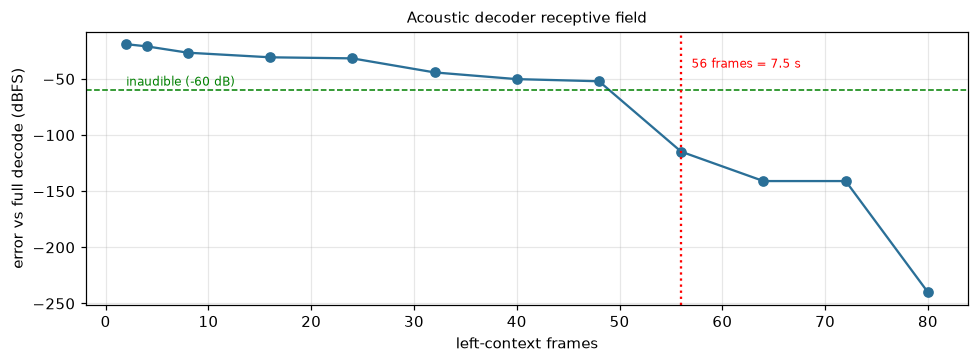

In [16]:
RECORDED = [(2,1.117e-01),(4,8.934e-02),(8,4.660e-02),(16,2.908e-02),(24,2.607e-02),
            (32,6.168e-03),(40,3.103e-03),(48,2.492e-03),(56,1.818e-06),(64,8.941e-08),
            (72,8.941e-08),(80,0.0)]
if live:
    lat = np.load(LAT_L); full = decode(lat); T = lat.shape[1]
    i = T - 3; tgt = full[i*FRAME:(i+1)*FRAME]
    rows = []
    for W in [w for w, _ in RECORDED if i - w >= 0]:
        s = i - W
        seg = decode(lat[:, s:i+1])[(i-s)*FRAME:(i-s+1)*FRAME]
        rows.append((W, np.abs(seg-tgt).max()))
else:
    rows = RECORDED

print("   W    max|diff|      dBFS     verdict")
for W, e in rows:
    db = 20*np.log10(e+1e-12)
    v = "inaudible" if db < -60 else ("marginal" if db < -40 else "AUDIBLE")
    print(f" {W:4d}   {e:.3e}   {db:8.1f}   {v}")

W_, E_ = np.array([r[0] for r in rows]), np.array([max(r[1], 1e-12) for r in rows])
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(W_, 20*np.log10(E_), "o-", color="#2a6f97")
ax.axhline(-60, ls="--", c="g", lw=1); ax.text(2, -56, "inaudible (-60 dB)", fontsize=8, color="g")
ax.axvline(56, ls=":", c="r"); ax.text(57, -40, "56 frames = 7.5 s", fontsize=8, color="r")
ax.set_xlabel("left-context frames"); ax.set_ylabel("error vs full decode (dBFS)")
ax.set_title("Acoustic decoder receptive field")
fig.tight_layout()
print("\n=> ~56 frames (7.5 s!). This is why naive per-frame decoding seamed every 3200 samples.")

### 9c. Does the streamed output actually match, and is it fast enough?

Correctness and viability are separate questions, and they get separate answers here.

In [17]:
b, s = audio["v7_lmkv_Carter.wav"], audio["v8_stream_Carter.wav"]
n = min(len(b), len(s)); d = np.abs(b[:n]-s[:n]).max()
print(f"batch vs streamed: max|diff| = {d:.3e} ({20*np.log10(d+1e-12):.1f} dBFS)")
print(f"  1/32768 = {1/32768:.3e}  -> {'BIT-EXACT (int16 quantisation only)' if d <= 1/32768+1e-9 else 'DIFFERS'}")
print(f"  seam ratio: batch {seam_ratio(b):.2f}x   streamed {seam_ratio(s):.2f}x   (1.0 = no seam)")

print("\nCost (measured, cpu_fp32):")
if live:
    lat = np.load(LAT_L)
    for n_ in [1, 6, 30, 87]:
        x = lat[:, :n_]; decode(x)
        t0 = time.perf_counter(); decode(x); ms = (time.perf_counter()-t0)*1000
        print(f"  batch of {n_:3d} frames: {ms:7.1f} ms -> {ms/n_:6.1f} ms/frame, RTF={ms/1000/(n_/FPS):.2f}")
else:
    print("""  batch of   1 frames:   237.5 ms ->  237.5 ms/frame, RTF=1.78
  batch of   6 frames:   326.6 ms ->   54.4 ms/frame, RTF=0.41
  batch of  30 frames:   884.6 ms ->   29.5 ms/frame, RTF=0.22
  batch of  87 frames:  2625.5 ms ->   30.2 ms/frame, RTF=0.23""")
print(f"""
Realtime budget at {FPS} Hz = {1000/FPS:.1f} ms/frame.

  batch decode                      RTF 0.22   -> 4.3x faster than realtime
  streamed, 56-frame context replay RTF ~11.5  -> 11x SLOWER than realtime

Cost is dominated by PER-CALL OVERHEAD, not context length (1 frame = 237 ms, but 30 frames =
30 ms/frame amortised), so shrinking the replay window cannot rescue it. Streaming is therefore
CORRECT but NOT viable; real streaming needs the decoder exported WITH its conv-state cache
(34 layers, 68 extra graph tensors, ~711 KB state). Not yet done.""")

batch vs streamed: max|diff| = 3.052e-05 (-90.3 dBFS)
  1/32768 = 3.052e-05  -> BIT-EXACT (int16 quantisation only)
  seam ratio: batch 0.93x   streamed 0.93x   (1.0 = no seam)

Cost (measured, cpu_fp32):


  batch of   1 frames:   131.9 ms ->  131.9 ms/frame, RTF=0.99


  batch of   6 frames:   295.0 ms ->   49.2 ms/frame, RTF=0.37


  batch of  30 frames:   778.2 ms ->   25.9 ms/frame, RTF=0.19


  batch of  87 frames:  2266.3 ms ->   26.0 ms/frame, RTF=0.20

Realtime budget at 7.5 Hz = 133.3 ms/frame.

  batch decode                      RTF 0.22   -> 4.3x faster than realtime
  streamed, 56-frame context replay RTF ~11.5  -> 11x SLOWER than realtime

Cost is dominated by PER-CALL OVERHEAD, not context length (1 frame = 237 ms, but 30 frames =
30 ms/frame amortised), so shrinking the replay window cannot rescue it. Streaming is therefore
CORRECT but NOT viable; real streaming needs the decoder exported WITH its conv-state cache
(34 layers, 68 extra graph tensors, ~711 KB state). Not yet done.


## Conclusions

1. **`eval.py` passing 5/5 proved nothing about audio.** Its LLM check is structural (op counts) and
   stage B skips the autoregressive loop, so all six targets passed while one could not decode a
   single token and two emitted babble. Every fix here came from running the driver and measuring
   the waveform.
2. **Identical failure across int4 and fp32 means structural, not precision.** That single check
   redirected the whole investigation away from quantization.
3. **Pitch statistics localised the last defect.** A median separation of ~86 Hz between the Carter
   and Emma prompts on identical text is positive evidence that conditioning works — stabilised
   pitch alone would not have proven that.
4. **Know your estimator's failure mode.** Autocorrelation F0 octave errors make min/max and ratio
   meaningless here; reporting them as vocal range would have been wrong.
5. **A metric that improves for the wrong reason is worse than no metric.** Pitch IQR is lowest on
   the *babble* sample, because a drone is maximally stable. Any "stability" score read on its own
   would have ranked the broken build first.
6. **Measure the system with its real inputs.** The receptive-field sweep was first run on random
   latents, which drive this decoder to near-silence — it returned a flat ~2.4e-05 "error" at every
   context width, i.e. the silence floor, and would have supported the conclusion that context does
   not matter. On real latents the same sweep shows a 56-frame dependency.
7. **Correct and viable are different claims.** Streamed decoding is bit-exact against batch, and
   still unusable at RTF 11.5. Reporting only the first would have been true and misleading.

### Remaining gaps

1. **Conv-state-cached `acoustic_decoder` export** — the only thing between this build and genuine
   streaming (§9c). 34 streaming conv layers → 68 extra graph tensors, ~711 KB state.
2. **v6 vs v7 unresolved by ear** (§8). The metrics do not separate them.
3. **No PyTorch-reference diff yet.** Every parity claim here rests on proxy measurements. The
   checkpoint and the `.pt` voice prompts are both local now, so running the reference pipeline and
   diffing waveforms is feasible and would settle it directly.